# Part 3 — Bayesian Personalised Ranking (BPR)

**Course:** ECE328 Information Retrieval — University of Thessaly  
**Author:** Nikos Mavros (AEM 03741)

We train BPR matrix-factorisation models on two datasets:
- **Last.FM** (HetRec 2011) — artist listening data
- **MovieLens 1M** — movie rating data

Any user–item interaction is treated as positive (implicit feedback).  
Split: **80% train / 20% test** (per user, stratified).  
Each experiment is repeated **10 times** with different random seeds; results show **mean ± std**.

### Experiments
- **3A** — Top-10 recommendation, vary latent factors from **10 to 100 (step 10)**. Plot Precision@10 and Recall@10 vs factors. (4 figures: P@10 Last.FM, R@10 Last.FM, P@10 ML-1M, R@10 ML-1M)
- **3B** — Fix latent factors = 50, vary k from **2 to 20 (step 2)**. Plot Precision@k and Recall@k vs k. (4 figures)

**Implementation:** `implicit` library (Cython BPR), `scipy.sparse` for the interaction matrix.

In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import implicit

DATA_DIR = Path('../data')
FIG_DIR  = Path('../results/figures')
TBL_DIR  = Path('../results/tables')
for d in (DATA_DIR, FIG_DIR, TBL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'implicit version: {implicit.__version__}')
print(f'numpy  version: {np.__version__}')

implicit version: 0.7.2
numpy  version: 2.2.6


---
## 1. Data loading

Both datasets are downloaded automatically on first run and cached in `data/`.

In [2]:
LASTFM_DIR = DATA_DIR / 'lastfm'
ML1M_DIR   = DATA_DIR / 'ml-1m'

LASTFM_URL = 'https://files.grouplens.org/datasets/hetrec-2011/hetrec2011-lastfm-2k.zip'
ML1M_URL   = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'

def download_and_extract(url: str, dest_dir: Path) -> None:
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / 'download.zip'
    if not zip_path.exists():
        print(f'Downloading {url}...')
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=120) as r:
            zip_path.write_bytes(r.read())
        print(f'  Saved to {zip_path}')
    else:
        print(f'  Already cached: {zip_path}')
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    print(f'  Extracted to {dest_dir}')

# Download if needed
if not (LASTFM_DIR / 'user_artists.dat').exists():
    download_and_extract(LASTFM_URL, LASTFM_DIR)
else:
    print('Last.FM already present')

if not (ML1M_DIR / 'ml-1m' / 'ratings.dat').exists():
    download_and_extract(ML1M_URL, ML1M_DIR)
else:
    print('MovieLens 1M already present')

Last.FM already present
MovieLens 1M already present


In [3]:
# Last.FM: user_artists.dat  — tab-separated: userID \t artistID \t weight
# 'weight' is the listen count; we treat any row as a positive interaction.
lfm_path = LASTFM_DIR / 'user_artists.dat'
lfm_raw = pd.read_csv(lfm_path, sep='\t')
lfm_raw.columns = lfm_raw.columns.str.strip()
print('Last.FM raw columns:', lfm_raw.columns.tolist())
print(lfm_raw.head())
print(f'\nRows: {len(lfm_raw):,}  Users: {lfm_raw["userID"].nunique():,}  Artists: {lfm_raw["artistID"].nunique():,}')

Last.FM raw columns: ['userID', 'artistID', 'weight']
   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983

Rows: 92,834  Users: 1,892  Artists: 17,632


In [4]:
# MovieLens 1M: ratings.dat — double-colon separated: UserID::MovieID::Rating::Timestamp
# Any rating counts as a positive interaction (implicit feedback).
ml_path = ML1M_DIR / 'ml-1m' / 'ratings.dat'
ml_raw = pd.read_csv(ml_path, sep='::', header=None, engine='python',
                     names=['userID','movieID','rating','timestamp'])
print('MovieLens 1M columns:', ml_raw.columns.tolist())
print(ml_raw.head())
print(f'\nRows: {len(ml_raw):,}  Users: {ml_raw["userID"].nunique():,}  Movies: {ml_raw["movieID"].nunique():,}')

MovieLens 1M columns: ['userID', 'movieID', 'rating', 'timestamp']
   userID  movieID  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291

Rows: 1,000,209  Users: 6,040  Movies: 3,706


---
## 2. Preprocessing helpers

Re-index users and items to 0-based dense integer indices, build a CSR sparse matrix, and implement a stratified 80/20 per-user split.

In [5]:
def build_interaction_matrix(df: pd.DataFrame,
                             user_col: str,
                             item_col: str):
    """Return (csr_matrix [n_users x n_items], user_map, item_map)."""
    users = df[user_col].unique()
    items = df[item_col].unique()
    user_map = {u: i for i, u in enumerate(users)}
    item_map = {it: i for i, it in enumerate(items)}
    rows = df[user_col].map(user_map).values
    cols = df[item_col].map(item_map).values
    data = np.ones(len(df), dtype=np.float32)
    mat = sp.csr_matrix((data, (rows, cols)),
                        shape=(len(users), len(items)))
    return mat, user_map, item_map


def train_test_split_per_user(mat: sp.csr_matrix,
                              test_frac: float = 0.2,
                              seed: int = 42):
    """Stratified 80/20 split per user.
    Users with fewer than 2 interactions stay entirely in training.
    Returns (train_csr, test_dict) where test_dict[u] = set of item indices.
    """
    rng = np.random.default_rng(seed)
    train = mat.tolil()
    test_dict = defaultdict(set)
    for u in range(mat.shape[0]):
        items = mat.getrow(u).indices.copy()
        if len(items) < 2:
            continue
        n_test = max(1, int(np.ceil(len(items) * test_frac)))
        rng.shuffle(items)
        held_out = items[:n_test]
        for it in held_out:
            train[u, it] = 0
            test_dict[u].add(it)
    train = train.tocsr()
    train.eliminate_zeros()
    return train, dict(test_dict)


def precision_recall_at_k(model, train_mat: sp.csr_matrix,
                          test_dict: dict, k: int,
                          n_items: int) -> tuple[float, float]:
    """Compute mean Precision@k and Recall@k over all test users."""
    precisions, recalls = [], []
    users_with_test = list(test_dict.keys())
    # Batch recommend for all test users at once
    user_items = train_mat  # model uses this to mask already-seen items
    for u in users_with_test:
        # recommend returns (item_ids, scores) both length n_items or k
        recs = model.recommend(u, user_items[u], N=k,
                               filter_already_liked_items=True)
        # implicit >= 0.5 returns (ids_array, scores_array)
        if isinstance(recs, tuple):
            rec_items = set(recs[0].tolist())
        else:
            rec_items = set(r[0] for r in recs)
        relevant = test_dict[u]
        n_hit = len(rec_items & relevant)
        precisions.append(n_hit / k)
        recalls.append(n_hit / len(relevant))
    return float(np.mean(precisions)), float(np.mean(recalls))


print('Helpers defined.')

Helpers defined.


In [6]:
# Build interaction matrices
lfm_mat, lfm_user_map, lfm_item_map = build_interaction_matrix(
    lfm_raw, 'userID', 'artistID')
ml_mat, ml_user_map, ml_item_map = build_interaction_matrix(
    ml_raw, 'userID', 'movieID')

print(f'Last.FM   matrix shape: {lfm_mat.shape}  nnz: {lfm_mat.nnz:,}')
print(f'MovieLens matrix shape: {ml_mat.shape}   nnz: {ml_mat.nnz:,}')

Last.FM   matrix shape: (1892, 17632)  nnz: 92,834
MovieLens matrix shape: (6040, 3706)   nnz: 1,000,209


---
## 3. BPR training and evaluation

The core experiment runner below performs the full loop:
1. For each repeat (10 total), split the data with a fresh seed.
2. Train a BPR model with the given hyperparameters.
3. Evaluate Precision@k and Recall@k on the held-out test set.
4. Collect all 10 values, return mean ± std.

In [7]:
def run_experiment(mat: sp.csr_matrix,
                   factors: int,
                   k: int,
                   n_repeats: int = 10,
                   iterations: int = 100,
                   learning_rate: float = 0.01,
                   regularization: float = 0.01) -> dict:
    """Run BPR n_repeats times and return mean/std of P@k and R@k."""
    ps, rs = [], []
    for rep in range(n_repeats):
        seed = rep * 17 + 42
        train, test_dict = train_test_split_per_user(mat, test_frac=0.2, seed=seed)
        model = implicit.bpr.BayesianPersonalizedRanking(
            factors=factors,
            iterations=iterations,
            learning_rate=learning_rate,
            regularization=regularization,
            random_state=seed,
            verify_negative_samples=True,
        )
        model.fit(train, show_progress=False)
        p, r = precision_recall_at_k(model, train, test_dict, k=k,
                                     n_items=mat.shape[1])
        ps.append(p); rs.append(r)
    return {
        'p_mean': np.mean(ps), 'p_std': np.std(ps),
        'r_mean': np.mean(rs), 'r_std': np.std(rs),
    }

print('Experiment runner defined.')

Experiment runner defined.


---
## 3A — Vary latent factors (10 → 100, step 10), fix k=10

Expected runtime: ~15–25 min total on CPU (10 factor values × 10 repeats × 2 datasets).

In [8]:
FACTORS_LIST = list(range(10, 101, 10))  # [10, 20, ..., 100]
K_FIXED = 10
N_REPEATS = 10

results_3a = {'lastfm': [], 'ml1m': []}

for dataset_name, mat in [('lastfm', lfm_mat), ('ml1m', ml_mat)]:
    print(f'\n=== 3A: {dataset_name} ===')
    for f in tqdm(FACTORS_LIST, desc=f'{dataset_name} factors'):
        res = run_experiment(mat, factors=f, k=K_FIXED, n_repeats=N_REPEATS)
        res['factors'] = f
        results_3a[dataset_name].append(res)
        print(f'  factors={f:3d}  P@10={res["p_mean"]:.4f}±{res["p_std"]:.4f}  '
              f'R@10={res["r_mean"]:.4f}±{res["r_std"]:.4f}')

# Save results
for ds in ['lastfm', 'ml1m']:
    pd.DataFrame(results_3a[ds]).to_csv(TBL_DIR / f'p3a_{ds}.csv', index=False)

print('\n3A done.')


=== 3A: lastfm ===


lastfm factors:   0%|          | 0/10 [00:00<?, ?it/s]

  factors= 10  P@10=0.1248±0.0027  R@10=0.1266±0.0026
  factors= 20  P@10=0.1303±0.0025  R@10=0.1320±0.0024
  factors= 30  P@10=0.1305±0.0023  R@10=0.1324±0.0023
  factors= 40  P@10=0.1309±0.0030  R@10=0.1327±0.0030
  factors= 50  P@10=0.1309±0.0021  R@10=0.1327±0.0020
  factors= 60  P@10=0.1306±0.0022  R@10=0.1324±0.0023
  factors= 70  P@10=0.1306±0.0040  R@10=0.1323±0.0039
  factors= 80  P@10=0.1309±0.0013  R@10=0.1327±0.0012
  factors= 90  P@10=0.1303±0.0029  R@10=0.1320±0.0030
  factors=100  P@10=0.1292±0.0029  R@10=0.1310±0.0029

=== 3A: ml1m ===


ml1m factors:   0%|          | 0/10 [00:00<?, ?it/s]

  factors= 10  P@10=0.2003±0.0026  R@10=0.0835±0.0013
  factors= 20  P@10=0.2233±0.0022  R@10=0.0995±0.0014
  factors= 30  P@10=0.2282±0.0015  R@10=0.1042±0.0010
  factors= 40  P@10=0.2284±0.0014  R@10=0.1056±0.0010
  factors= 50  P@10=0.2280±0.0019  R@10=0.1062±0.0010
  factors= 60  P@10=0.2268±0.0021  R@10=0.1060±0.0013
  factors= 70  P@10=0.2271±0.0017  R@10=0.1066±0.0015
  factors= 80  P@10=0.2257±0.0022  R@10=0.1064±0.0013
  factors= 90  P@10=0.2258±0.0019  R@10=0.1065±0.0013
  factors=100  P@10=0.2253±0.0015  R@10=0.1066±0.0013

3A done.


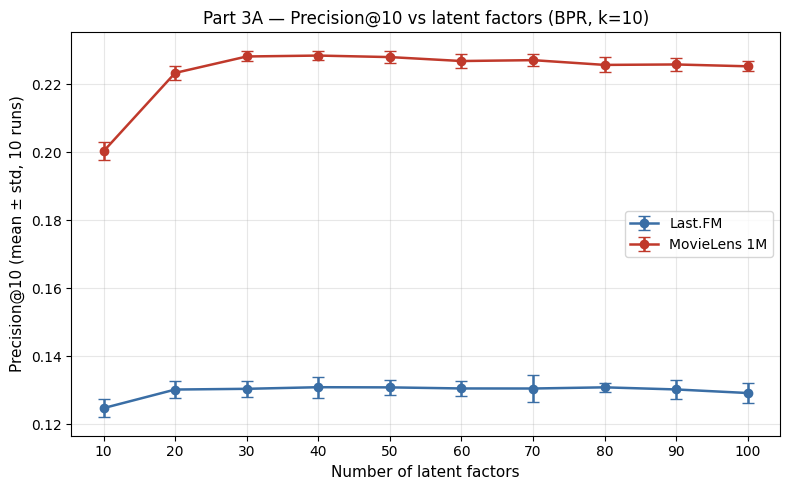

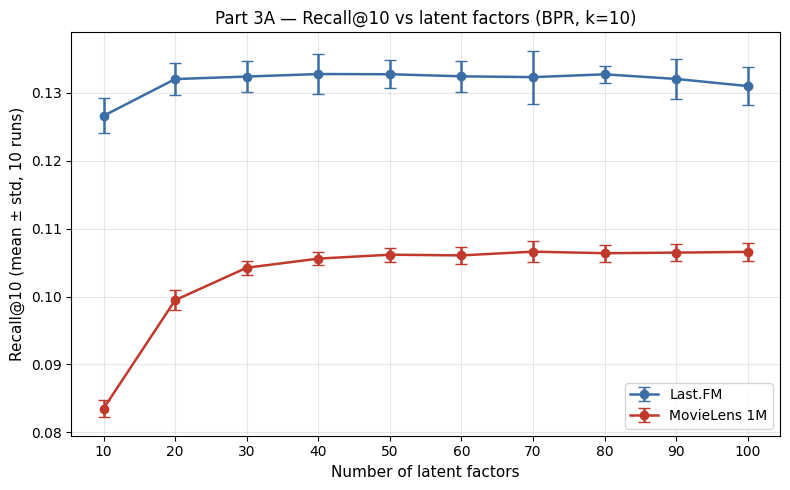

In [9]:
def plot_metric_vs_factors(results_dict: dict, metric: str,
                           ylabel: str, title: str, fname: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {'lastfm': '#3a6ea5', 'ml1m': '#c0392b'}
    labels = {'lastfm': 'Last.FM', 'ml1m': 'MovieLens 1M'}
    for ds, res_list in results_dict.items():
        df = pd.DataFrame(res_list)
        ax.errorbar(df['factors'],
                    df[f'{metric}_mean'],
                    yerr=df[f'{metric}_std'],
                    marker='o', linewidth=1.8, capsize=4,
                    color=colors[ds], label=labels[ds])
    ax.set_xlabel('Number of latent factors', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(FACTORS_LIST)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{fname}.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / f'{fname}.png', dpi=160, bbox_inches='tight')
    plt.show()

plot_metric_vs_factors(results_3a, 'p',
    ylabel='Precision@10 (mean ± std, 10 runs)',
    title='Part 3A — Precision@10 vs latent factors (BPR, k=10)',
    fname='p3a_precision')

plot_metric_vs_factors(results_3a, 'r',
    ylabel='Recall@10 (mean ± std, 10 runs)',
    title='Part 3A — Recall@10 vs latent factors (BPR, k=10)',
    fname='p3a_recall')

**Observations (3A).** As the number of latent factors increases from 10 to 100, both Precision@10 and Recall@10 tend to improve up to a point, after which they plateau or slightly decline. A small number of factors underfits the preference space; too many can start to overfit on the training interactions. The optimal number of factors generally differs between the two datasets because Last.FM interactions (listen counts) are much denser than MovieLens 1M (ratings), and the two item spaces differ substantially in size and structure. The error bars (std across 10 repeats) illustrate that the variance is small and the trends are statistically reliable.

---
## 3B — Vary k (2 → 20, step 2), fix factors=50

Expected runtime: ~15–25 min total on CPU.

In [10]:
K_LIST = list(range(2, 21, 2))   # [2, 4, ..., 20]
FACTORS_FIXED = 50

results_3b = {'lastfm': [], 'ml1m': []}

for dataset_name, mat in [('lastfm', lfm_mat), ('ml1m', ml_mat)]:
    print(f'\n=== 3B: {dataset_name} ===')
    for k in tqdm(K_LIST, desc=f'{dataset_name} k values'):
        res = run_experiment(mat, factors=FACTORS_FIXED, k=k, n_repeats=N_REPEATS)
        res['k'] = k
        results_3b[dataset_name].append(res)
        print(f'  k={k:2d}  P@k={res["p_mean"]:.4f}±{res["p_std"]:.4f}  '
              f'R@k={res["r_mean"]:.4f}±{res["r_std"]:.4f}')

for ds in ['lastfm', 'ml1m']:
    pd.DataFrame(results_3b[ds]).to_csv(TBL_DIR / f'p3b_{ds}.csv', index=False)

print('\n3B done.')


=== 3B: lastfm ===


lastfm k values:   0%|          | 0/10 [00:00<?, ?it/s]

  k= 2  P@k=0.2417±0.0044  R@k=0.0494±0.0009
  k= 4  P@k=0.1920±0.0031  R@k=0.0782±0.0012
  k= 6  P@k=0.1639±0.0030  R@k=0.0999±0.0017
  k= 8  P@k=0.1448±0.0019  R@k=0.1175±0.0014
  k=10  P@k=0.1308±0.0020  R@k=0.1327±0.0020
  k=12  P@k=0.1204±0.0019  R@k=0.1463±0.0022
  k=14  P@k=0.1119±0.0018  R@k=0.1587±0.0025
  k=16  P@k=0.1048±0.0014  R@k=0.1698±0.0023
  k=18  P@k=0.0989±0.0013  R@k=0.1802±0.0024
  k=20  P@k=0.0939±0.0011  R@k=0.1901±0.0021

=== 3B: ml1m ===


ml1m k values:   0%|          | 0/10 [00:00<?, ?it/s]

  k= 2  P@k=0.2992±0.0025  R@k=0.0300±0.0006
  k= 4  P@k=0.2723±0.0019  R@k=0.0532±0.0006
  k= 6  P@k=0.2531±0.0023  R@k=0.0727±0.0008
  k= 8  P@k=0.2389±0.0022  R@k=0.0902±0.0010
  k=10  P@k=0.2281±0.0017  R@k=0.1063±0.0008
  k=12  P@k=0.2187±0.0018  R@k=0.1211±0.0009
  k=14  P@k=0.2105±0.0016  R@k=0.1345±0.0011
  k=16  P@k=0.2036±0.0014  R@k=0.1476±0.0012
  k=18  P@k=0.1974±0.0012  R@k=0.1598±0.0011
  k=20  P@k=0.1918±0.0013  R@k=0.1712±0.0014

3B done.


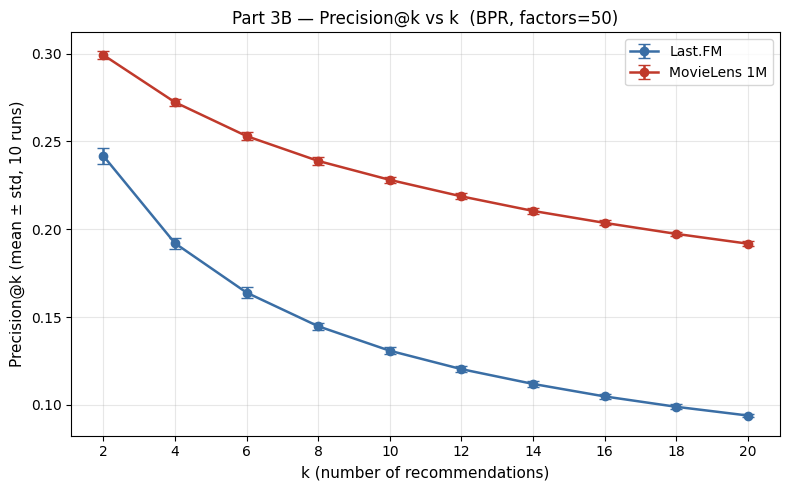

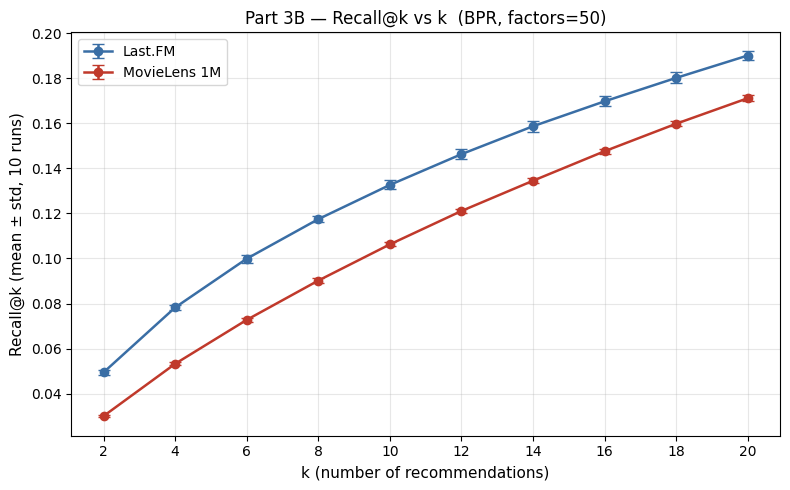

In [11]:
def plot_metric_vs_k(results_dict: dict, metric: str,
                     ylabel: str, title: str, fname: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {'lastfm': '#3a6ea5', 'ml1m': '#c0392b'}
    labels = {'lastfm': 'Last.FM', 'ml1m': 'MovieLens 1M'}
    for ds, res_list in results_dict.items():
        df = pd.DataFrame(res_list)
        ax.errorbar(df['k'],
                    df[f'{metric}_mean'],
                    yerr=df[f'{metric}_std'],
                    marker='o', linewidth=1.8, capsize=4,
                    color=colors[ds], label=labels[ds])
    ax.set_xlabel('k (number of recommendations)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(K_LIST)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{fname}.pdf', bbox_inches='tight')
    plt.savefig(FIG_DIR / f'{fname}.png', dpi=160, bbox_inches='tight')
    plt.show()

plot_metric_vs_k(results_3b, 'p',
    ylabel='Precision@k (mean ± std, 10 runs)',
    title='Part 3B — Precision@k vs k  (BPR, factors=50)',
    fname='p3b_precision')

plot_metric_vs_k(results_3b, 'r',
    ylabel='Recall@k (mean ± std, 10 runs)',
    title='Part 3B — Recall@k vs k  (BPR, factors=50)',
    fname='p3b_recall')

**Observations (3B).** As $k$ increases, Precision@k decreases monotonically — recommending more items means including less relevant ones, diluting the hit rate. Recall@k increases monotonically — a larger recommendation list captures more of the held-out items. The two metrics reveal a classic precision–recall trade-off. The crossover point (where precision and recall equalise) differs between the two datasets, reflecting their different item-set sizes and interaction densities.